In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from visualization.plot import plot_clustering_on_umap
from visualization.samples_plot import show_clustering_samples
from clustering.hdbscan.consensus import consensus_clustering_from_labels_hdbscan
from clustering.hdbscan.consensus_dbcv import dbcv_per_cluster_consensus

PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings_224"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

1664


In [21]:
#X_reduced_variance = VarianceThreshold(threshold=1e-8).fit_transform(embedding)

#embedding_scaled = StandardScaler().fit_transform(X_reduced_variance)
embedding_l2 = normalize(embedding, norm="l2")

pca_85 = PCA(n_components=0.85)
pca_85_embedding = pca_85.fit_transform(embedding_l2)

#print("Shape dopo PCA:", pca_95_embedding.shape)

#pca_95_embedding_l2 = normalize(pca_95_embedding, norm="l2")

#pca_100_embedding_l2 = normalize(pca_100_embedding, norm="l2")

In [22]:
from clustering.hdbscan.score import consensus_param_score, consensus_param_metrics
import pandas as pd
from tqdm.auto import tqdm

from clustering.hdbscan.fit import fit_umap_hdbscan
from clustering.hdbscan.params import make_umap_hdbscan_grid_params

labels_for_consensus = []
umap_embeddings_for_consensus = []

MIN_CLUSTER_SIZE = max(10, round(0.03 * n_samples))

for seed in range(0, 50):
    labels, umap_embedding = fit_umap_hdbscan(
        X=pca_85_embedding,
        seed=None,
        n_components=10,
        n_neighbors=max(15, round(0.05 * n_samples)),
        min_dist=0.02,
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=4,
    )

    labels_for_consensus.append(labels)
    umap_embeddings_for_consensus.append(umap_embedding)


consensus_labels, probabilities, diagnostics = consensus_clustering_from_labels_hdbscan(
    labels_for_consensus,
    n_clusters="median",  # oppure n_clusters=4 se vuoi forzare 4 macrocluster
    max_noise_frequency=0.40,
    min_consensus_strength=0.60,
    min_final_cluster_size=MIN_CLUSTER_SIZE,
    strength_stat="mean",
    return_diagnostics=True,
)

dbcv_consensus = dbcv_per_cluster_consensus(
    consensus_labels,
    umap_embeddings_for_consensus,
)

In [23]:
cluster_dbcv_df = (
    dbcv_consensus
    .loc[:, ["cluster", "size", "dbcv_median"]]
    .rename(columns={"dbcv_median": "dbcv"})
    .sort_values("cluster")
    .reset_index(drop=True)
)

cluster_dbcv_df

,cluster,size,dbcv
0,-1,172,NaN
1,0,62,0.185999
2,1,134,0.270778
3,2,129,0.102928
4,3,63,0.485390
5,4,42,0.505816
6,5,35,0.202906
7,6,40,0.440604


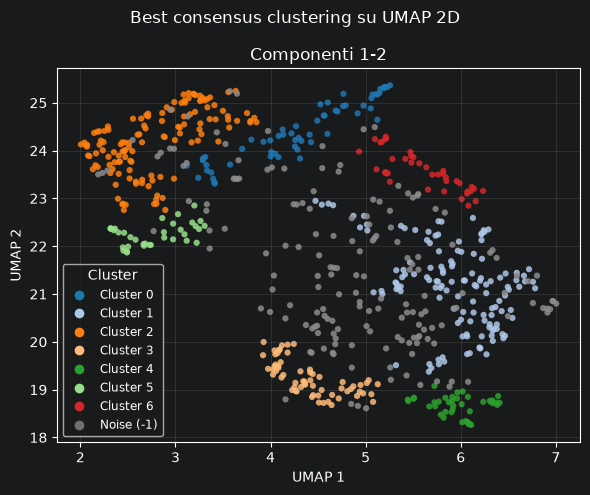

In [24]:
plot_figure, plot_axes = plot_clustering_on_umap(
    pca_85_embedding,
    consensus_labels,
    title="Best consensus clustering su UMAP 2D",
    metric="euclidean",
    min_dist=0.02,
    n_neighbors=max(15, round(0.05 * n_samples)),
)

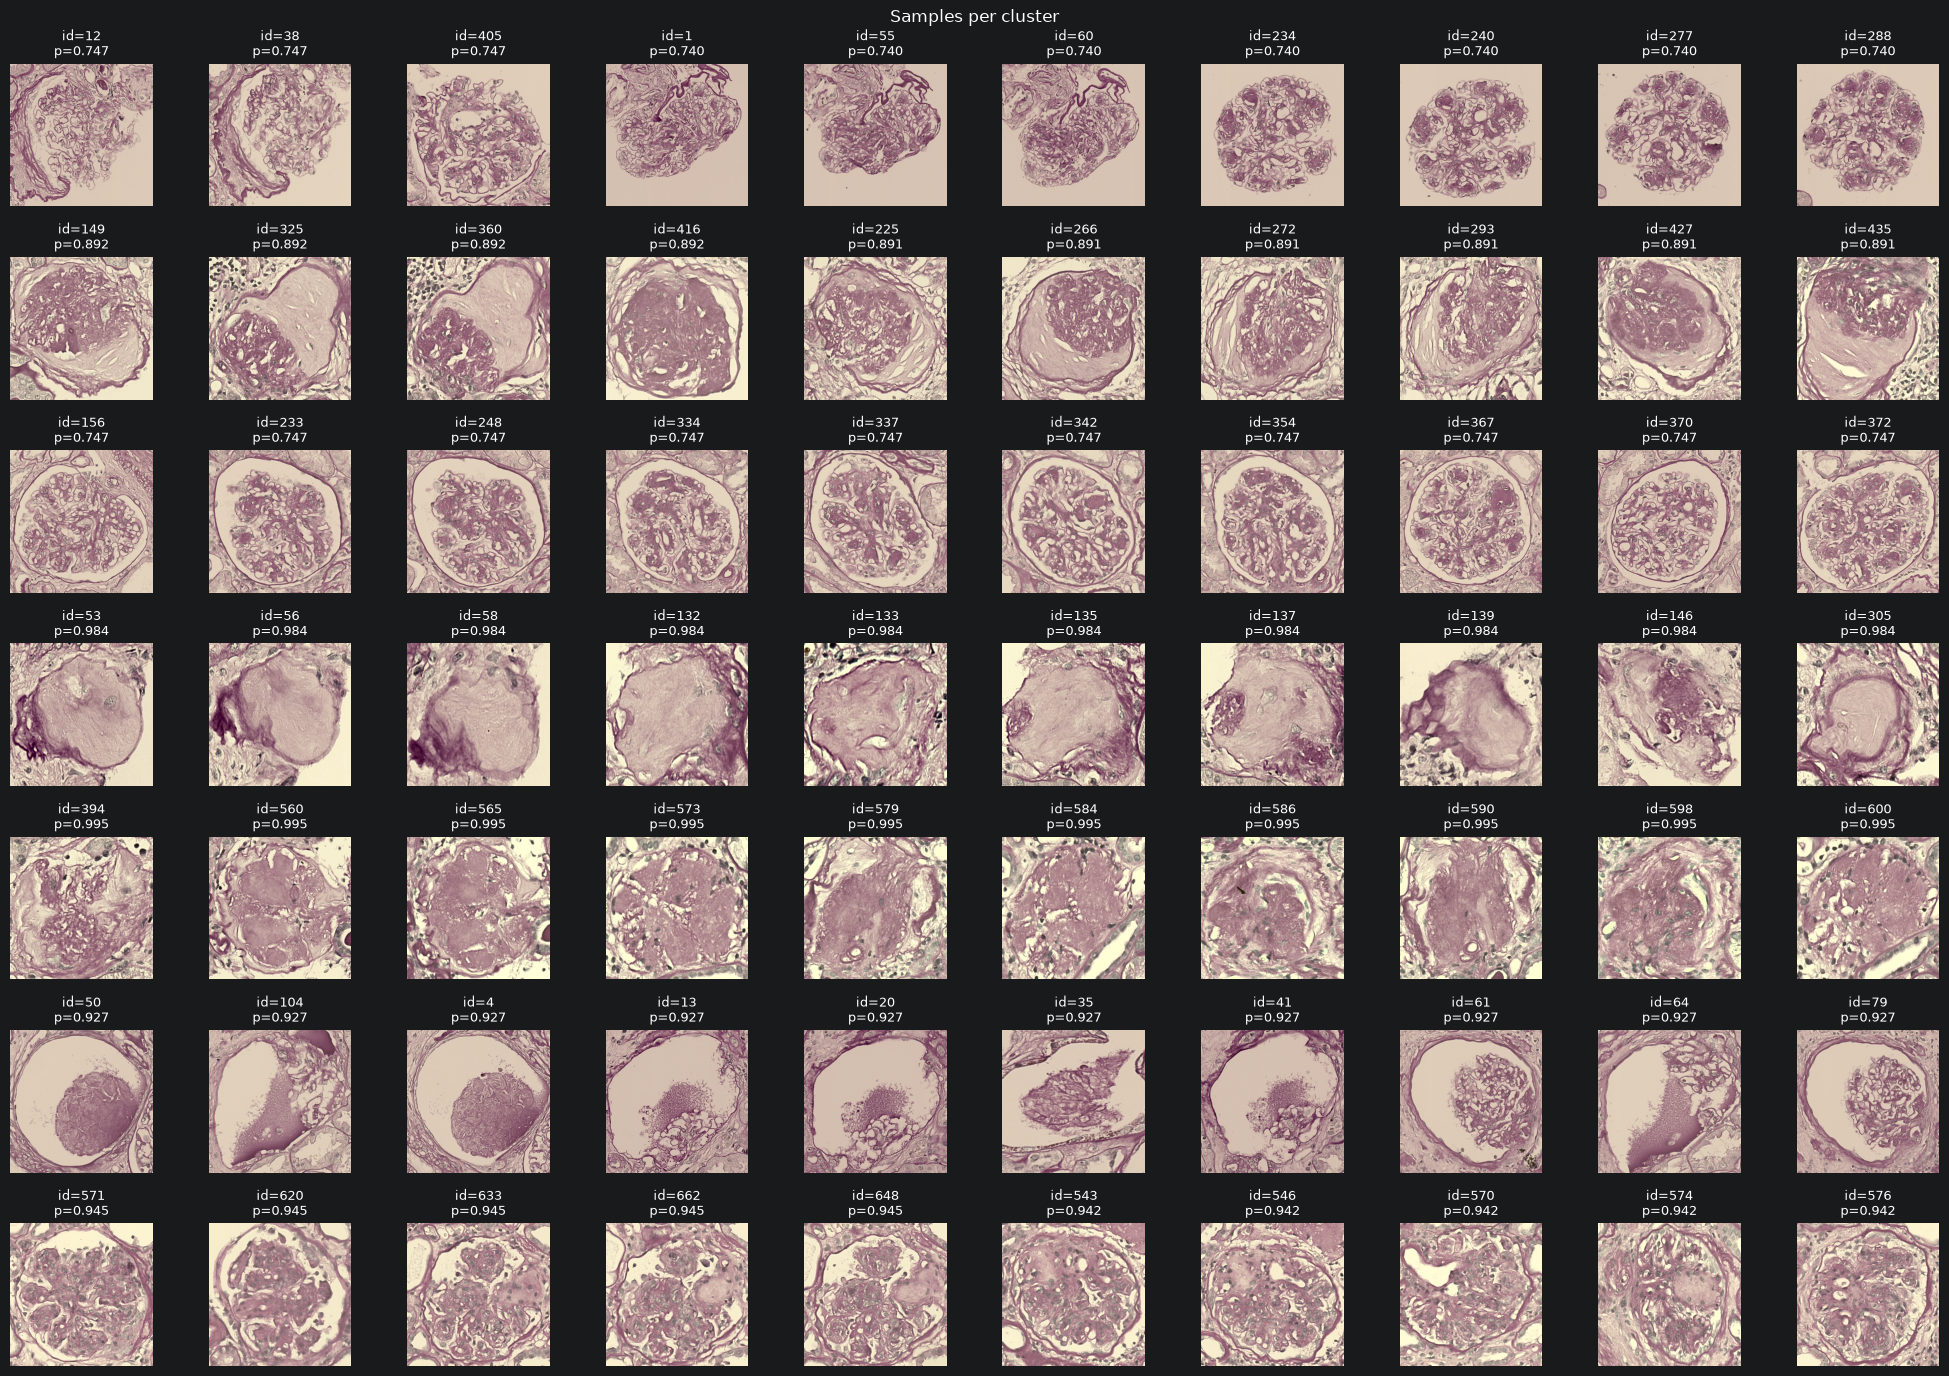

In [25]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=consensus_labels,
    probabilities=probabilities,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)